<a href="https://colab.research.google.com/github/FABIANXD04/Ciencia-de-Datos/blob/main/APP_M3_Python_IPS_Salud_Meridiano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IPS Salud Meridiano - Protocolo de Limpieza y Análisis de Datos (Módulo 3)

Este cuaderno contiene el flujo completo para el tratamiento del registro sucio de la IPS Salud Meridiano:
1. **Manejo de cadenas y limpieza de texto**
2. **Limpieza con Pandas, tipos de datos y deduplicación**
3. **Agregaciones e imputación por grupo**
4. **Visualizaciones de calidad de datos y análisis**

Selecciona el archivo "accidents-1.csv":


Saving accidents-1.csv to accidents-1 (2).csv
✓ Archivo cargado exitosamente. Filas iniciales: 238522

=== 1. ANÁLISIS DE FECHAS Y DÍAS DE LA SEMANA ===
Accidentes por día de la semana:
DAY_NAME
Friday       37886
Thursday     36254
Tuesday      35651
Wednesday    35188
Monday       34719
Saturday     31784
Sunday       27040
Name: count, dtype: int64
------------------------------------------------------------

=== 2. ACCIDENTES POR MUNICIPIO (BOROUGH) ===
BOROUGH
BROOKLYN         76253
QUEENS           67120
MANHATTAN        48749
BRONX            37709
STATEN ISLAND     8691
Name: count, dtype: int64
------------------------------------------------------------

=== 3. PRINCIPALES CAUSAS DE ACCIDENTES ===
Unspecified                       190096
Driver Inattention/Distraction     61752
Failure to Yield Right-of-Way      19641
Following Too Closely              17293
Backing Unsafely                   14835
Passing Too Closely                12631
Passing or Lane Usage Improper     11

/tmp/ipykernel_1922/4086525556.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DAY_NAME', order=dias_orden, ax=axes[0], palette='viridis')
/tmp/ipykernel_1922/4086525556.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


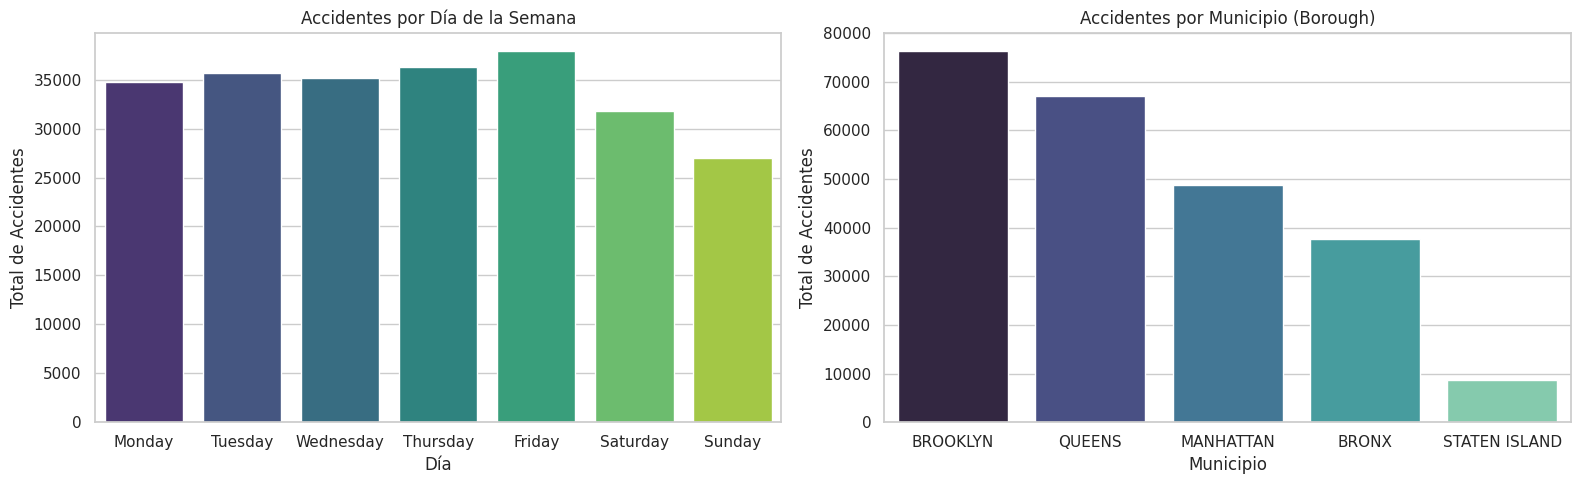

In [13]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print('Selecciona el archivo "accidents-1.csv":')
uploaded = files.upload()

if uploaded:
  filename = list(uploaded.keys())[0]

  # Lectura con separador ';' habitual en este dataset
  df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=';', low_memory=False)
  print(f'✓ Archivo cargado exitosamente. Filas iniciales: {len(df)}\n')

  # 1. Procesamiento de Fechas
  print('=== 1. ANÁLISIS DE FECHAS Y DÍAS DE LA SEMANA ===')
  df['DATE_dt'] = pd.to_datetime(df['DATE'], format='%m/%d/%Y', errors='coerce')
  df['DAY_NAME'] = df['DATE_dt'].dt.day_name()

  print('Accidentes por día de la semana:')
  print(df['DAY_NAME'].value_counts())
  print('-' * 60)

  # 2. Análisis por Municipio (Borough)
  print('\n=== 2. ACCIDENTES POR MUNICIPIO (BOROUGH) ===')
  print(df['BOROUGH'].value_counts())
  print('-' * 60)

  # 3. Principales Factores Contribuyentes
  print('\n=== 3. PRINCIPALES CAUSAS DE ACCIDENTES ===')
  factor_cols = [f'CONTRIBUTING FACTOR VEHICLE {i}' for i in range(1, 6)]
  factores = (
      df[factor_cols]
      .apply(lambda row: set(row.dropna()), axis=1)
      .explode()
      .value_counts()
  )
  print(factores.head(10))
  print('-' * 60)

  # 4. Visualización
  fig, axes = plt.subplots(1, 2, figsize=(16, 5))

  # Gráfico 1: Accidentes por Día de la Semana
  dias_orden = [
      'Monday',
      'Tuesday',
      'Wednesday',
      'Thursday',
      'Friday',
      'Saturday',
      'Sunday',
  ]
  sns.countplot(data=df, x='DAY_NAME', order=dias_orden, ax=axes[0], palette='viridis')
  axes[0].set_title('Accidentes por Día de la Semana')
  axes[0].set_xlabel('Día')
  axes[0].set_ylabel('Total de Accidentes')

  # Gráfico 2: Accidentes por Borough
  sns.countplot(
      data=df,
      x='BOROUGH',
      order=df['BOROUGH'].value_counts().index,
      ax=axes[1],
      palette='mako',
  )
  axes[1].set_title('Accidentes por Municipio (Borough)')
  axes[1].set_xlabel('Municipio')
  axes[1].set_ylabel('Total de Accidentes')

  plt.tight_layout()
  plt.show()

else:
  print('No se seleccionó ningún archivo.')
